# 🏎️ Nina's F1 Predictions: 2026 Miami Grand Prix (Round 4)
## Miami International Autodrome — May 1-3, 2026

**Model version:** v1.0+Q (retrospective)
**Confidence:** HIGH

### What This Is

A machine learning model that predicts Formula 1 race results from 24 features — the same kinds of data a race engineer considers when building race strategy. The model trains on every race through the round before this one (2026 weighted 10x over 2023-2025 history), takes the **actual qualifying grid** and **live qualifying sector times** for this weekend, then runs 10,000 simulated races to estimate podium probabilities.

> **This is a reconstructed prediction.** The model was rebuilt using only data available before the Miami GP — nothing from the race itself enters the model — so the accuracy check in the final section is a fair test. It backfills the season scoreboard for a race weekend that ran before the model was caught up.


In [1]:
import sys; sys.path.insert(0, '../scripts')
import f1lib
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background'); plt.rcParams['figure.figsize'] = (10, 6)
f1lib.enable_cache('../data/cache')

EVENT, RND, TRACK = 'Miami', 4, 'Miami International Autodrome'
SECTORS = '../data/miami_sectors.csv'

df, weather, lap_stats, advanced, lk = f1lib.load_data('../data')
target_seq = df[(df.Year == 2026) & (df.Round == RND)]['race_seq'].iloc[0]

sec = f1lib.track_sector_deltas(SECTORS)
cp_season = f1lib.season_pace(df, 2026, target_seq)
speeds_2026 = lap_stats[lap_stats.Year == 2026].groupby('Team')['avg_speed_st'].mean().to_dict()

feat = f1lib.engineer_features(df, lap_stats, lk, sec, target_seq, cp_season)
model, loo_mae, residual_std = f1lib.train(feat, target_seq)

print('=' * 60)
print(f'  🤖 XGBOOST v1.0 — 24 features, trained through Round {RND-1}')
print('=' * 60)
print(f'  Training rows: {len(feat[feat.race_seq < target_seq]):,}')
print(f'  Leave-one-out MAE: {loo_mae:.2f} positions (honest)')
print(f'  Residual StdDev:   {residual_std:.2f}')

imp = sorted(zip(f1lib.FEATURE_COLS, model.feature_importances_), key=lambda x: -x[1])
print('\n  Top features:')
for f, s in imp[:8]:
    print(f'    {f:25s} {s:.3f}')


Matplotlib is building the font cache; this may take a moment.


  🤖 XGBOOST v1.0 — 24 features, trained through Round 3
  Training rows: 1,463
  Leave-one-out MAE: 2.37 positions (honest)
  Residual StdDev:   2.82

  Top features:
    grid_position             0.222
    car_speed                 0.109
    sector1_delta             0.098
    driver_avg_finish         0.067
    team_pit_strategy         0.057
    car_pace                  0.048
    sector3_delta             0.040
    team_changed              0.039


## 1. Qualifying & Blended Car Pace

Grid position is the model's single strongest predictor. This weekend's actual qualifying result sets the starting grid, and the team-level pace is a 30/70 blend of season-to-date form and qualifying performance. Live Miami sector deltas from qualifying replace the historical track profile.

In [2]:
wk = f1lib.weekend(2026, EVENT, df, {'pace': cp_season, 'speed': speeds_2026})
wk['race_name'] = EVENT

grid_sorted = sorted(wk['grid'].items(), key=lambda x: x[1])
print('=' * 70)
print(f'  🏁 QUALIFYING GRID — 2026 {EVENT} GP')
print('=' * 70)
print(f"\n  {'Pos':>3s}  {'Driver':22s}  {'Team':18s}  {'Blend Pace':>10s}")
print('  ' + '-' * 60)
for name, pos in grid_sorted:
    t = wk['team_map'].get(name, '')
    print(f"  P{pos:>2d}  {name:22s}  {t:18s}  P{wk['car_pace'].get(t, 15):>6.1f}")

print(f"\n  🌡️ Race conditions: {wk['temp']:.1f}°C, {wk['humidity']:.0f}% humidity, {'WET' if wk['rain'] else 'DRY'}")


  🏁 QUALIFYING GRID — 2026 Miami GP

  Pos  Driver                  Team                Blend Pace
  ------------------------------------------------------------
  P 1  Kimi Antonelli          Mercedes            P   2.6
  P 2  Max Verstappen          Red Bull Racing     P  11.9
  P 3  Charles Leclerc         Ferrari             P   4.3
  P 4  Lando Norris            McLaren             P   7.4
  P 5  George Russell          Mercedes            P   2.6
  P 6  Lewis Hamilton          Ferrari             P   4.3
  P 7  Oscar Piastri           McLaren             P   7.4
  P 8  Franco Colapinto        Alpine              P   9.1
  P 9  Pierre Gasly            Alpine              P   9.1
  P10  Nico Hulkenberg         Audi                P  15.2
  P11  Liam Lawson             Racing Bulls        P  12.6
  P12  Oliver Bearman          Haas F1 Team        P  12.5
  P13  Carlos Sainz            Williams            P  14.4
  P14  Esteban Ocon            Haas F1 Team        P  12.5
  P15  Alexa

## 2. Predicted Finish

Each driver's predicted finishing position, with the inputs that drove it: grid (actual qualifying), car (blended team pace), and the position change the model expects relative to the grid.

In [3]:
preds = f1lib.predict(df, feat, model, lk, wk)

print('=' * 80)
print(f'  🏁 PREDICTED FINISH — 2026 {EVENT} GP')
print('=' * 80)
print(f"\n  {'Pos':>3s}  {'Driver':22s}  {'Team':18s}  {'Grid':>4s}  {'Pred':>5s}  {'ΔGrid':>5s}")
print('  ' + '-' * 70)
for p in preds:
    d = p['Grid'] - p['Rank']
    ds = f'+{d}' if d > 0 else (f'{d}' if d < 0 else '=')
    print(f"  P{p['Rank']:>2d}  {p['Driver']:22s}  {p['Team']:18s}  P{p['Grid']:>2.0f}  P{p['Predicted']:>4.1f}  {ds:>5s}")


  🏁 PREDICTED FINISH — 2026 Miami GP

  Pos  Driver                  Team                Grid   Pred  ΔGrid
  ----------------------------------------------------------------------
  P 1  Kimi Antonelli          Mercedes            P 1  P 1.3      =
  P 2  Charles Leclerc         Ferrari             P 3  P 3.0     +1
  P 3  Lando Norris            McLaren             P 4  P 3.3     +1
  P 4  Max Verstappen          Red Bull Racing     P 2  P 3.3     -2
  P 5  George Russell          Mercedes            P 5  P 3.9      =
  P 6  Lewis Hamilton          Ferrari             P 6  P 6.4      =
  P 7  Oscar Piastri           McLaren             P 7  P 7.0      =
  P 8  Oliver Bearman          Haas F1 Team        P12  P 8.3     +4
  P 9  Pierre Gasly            Alpine              P 9  P 9.1      =
  P10  Nico Hulkenberg         Audi                P10  P10.0      =
  P11  Franco Colapinto        Alpine              P 8  P11.1     -3
  P12  Carlos Sainz            Williams            P13  P11.

## 3. Podium Probabilities (10,000 Simulated Races)

Rather than a single outcome, the model simulates the race 10,000 times with realistic randomness — mechanical failures, a 33% safety-car chance, and grid-dependent chaos (midfield is messier than the front row). The result is a probability for each driver.

  🎲 PODIUM PROBABILITIES — 2026 Miami GP

  Driver                  Team                Grid     Win   Podium    Top5
  ------------------------------------------------------------------------
  Kimi Antonelli          Mercedes            P 1   43.8%    82.4%   96.1%  █████████████████████
  Lando Norris            McLaren             P 4   16.1%    48.3%   75.3%  ████████
  Charles Leclerc         Ferrari             P 3   13.0%    52.3%   83.3%  ██████
  George Russell          Mercedes            P 5   10.5%    37.1%   67.0%  █████
  Max Verstappen          Red Bull Racing     P 2   10.2%    45.5%   80.3%  █████
  Lewis Hamilton          Ferrari             P 6    1.7%    10.8%   29.9%  
  Oliver Bearman          Haas F1 Team        P12    1.7%     7.0%   16.6%  
  Oscar Piastri           McLaren             P 7    1.3%     7.5%   22.9%  
  Pierre Gasly            Alpine              P 9    0.7%     4.1%   10.7%  
  Nico Hulkenberg         Audi                P10    0.5%     2.3%   

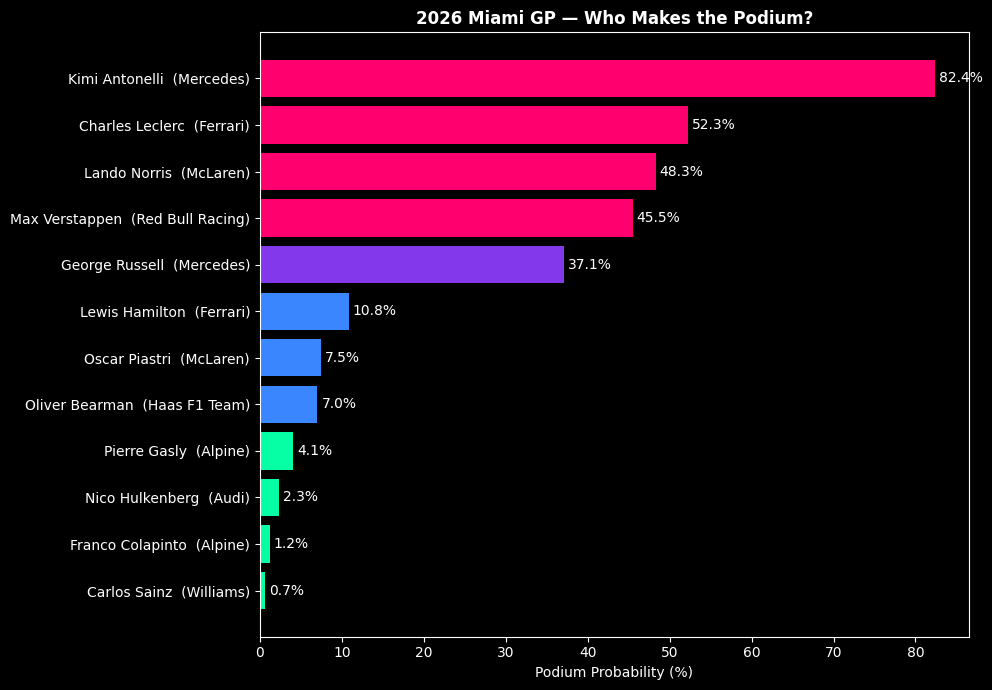

In [4]:
sims = f1lib.simulate(preds, residual_std)
n = sims['n']
prob = [{'Driver': p['Driver'], 'Team': p['Team'], 'Grid': p['Grid'],
         'Win': sims['win'][p['Driver']]/n*100, 'Podium': sims['podium'][p['Driver']]/n*100,
         'Top5': sims['top5'][p['Driver']]/n*100, 'Top10': sims['top10'][p['Driver']]/n*100}
        for p in preds]
prob_df = pd.DataFrame(prob).sort_values('Win', ascending=False)

print('=' * 80)
print(f'  🎲 PODIUM PROBABILITIES — 2026 {EVENT} GP')
print('=' * 80)
print(f"\n  {'Driver':22s}  {'Team':18s}  {'Grid':>4s}  {'Win':>6s}  {'Podium':>7s}  {'Top5':>6s}")
print('  ' + '-' * 72)
for _, r in prob_df.head(12).iterrows():
    bar = '█' * int(r['Win']/2)
    print(f"  {r['Driver']:22s}  {r['Team']:18s}  P{r['Grid']:>2.0f}  {r['Win']:>5.1f}%  {r['Podium']:>6.1f}%  {r['Top5']:>5.1f}%  {bar}")

fig, ax = plt.subplots(figsize=(10, 7))
t12 = prob_df.head(12).sort_values('Podium')
colors = ['#ff006e' if p > 40 else '#8338ec' if p > 15 else '#3a86ff' if p > 5 else '#06ffa5' for p in t12['Podium']]
bars = ax.barh(t12['Driver'] + '  (' + t12['Team'] + ')', t12['Podium'], color=colors)
for b, v in zip(bars, t12['Podium']):
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Podium Probability (%)')
ax.set_title(f'2026 {EVENT} GP — Who Makes the Podium?', fontweight='bold')
plt.tight_layout(); plt.show()


## 4. Race Results & Model Accuracy

The race has run — time to grade the model. Predicted order against the official classification: position-by-position error, podium / top-5 / top-10 accuracy, and the standout calls and misses. These numbers feed the season scoreboard.

  🏁 OFFICIAL RESULTS vs MODEL — 2026 Miami GP

  Fin  Driver                  Team                Pred   Err  Status
  ------------------------------------------------------------------------------
  P 1  Kimi Antonelli          Mercedes            P 1     0  Finished 🎯
  P 2  Lando Norris            McLaren             P 3     1  Finished 
  P 3  Oscar Piastri           McLaren             P 7     4  Finished 
  P 4  George Russell          Mercedes            P 5     1  Finished 
  P 5  Max Verstappen          Red Bull Racing     P 4     1  Finished 
  P 6  Lewis Hamilton          Ferrari             P 6     0  Finished 🎯
  P 7  Franco Colapinto        Alpine              P11     4  Finished 
  P 8  Charles Leclerc         Ferrari             P 2     6  Finished 
  P 9  Carlos Sainz            Williams            P12     3  Finished 
  P10  Alexander Albon         Williams            P16     6  Finished 
  P11  Oliver Bearman          Haas F1 Team        P 8     3  Lapped 
  P12  Gab

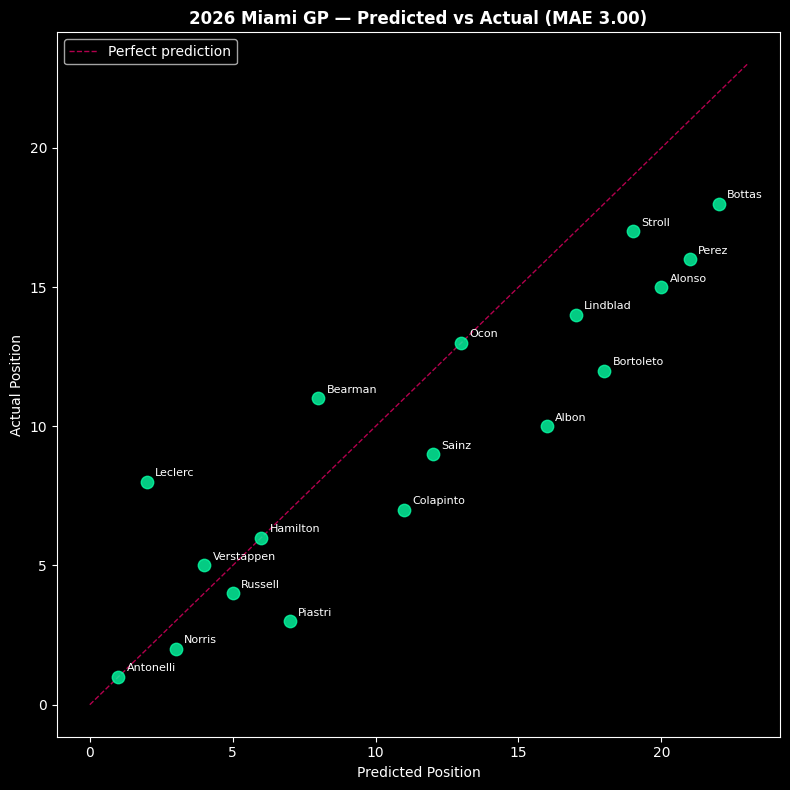

In [5]:
g = f1lib.grade(preds, wk['race_results'])

print('=' * 85)
print(f'  🏁 OFFICIAL RESULTS vs MODEL — 2026 {EVENT} GP')
print('=' * 85)
print(f"\n  {'Fin':>3s}  {'Driver':22s}  {'Team':18s}  {'Pred':>4s}  {'Err':>4s}  {'Status'}")
print('  ' + '-' * 78)
for r in sorted(g['rows'], key=lambda r: (pd.isna(r['Actual']), r['Actual'] if pd.notna(r['Actual']) else 99)):
    es = f"{r['Err']:.0f}" if r['Err'] is not None else 'DNF'
    hit = '🎯' if r['Err'] == 0 else ''
    fin = f"P{r['Actual']:>2.0f}" if pd.notna(r['Actual']) else ' - '
    print(f"  {fin}  {r['Driver']:22s}  {r['Team']:18s}  P{r['PredRank']:>2d}  {es:>4s}  {r['Status']} {hit}")

print(f"\n  📊 SCORECARD")
print('  ' + '-' * 55)
print(f"  Predicted winner:  {g['winner_pred']}")
print(f"  Actual winner:     {g['winner_actual']}  {'✅' if g['winner_hit'] else '❌'}")
print(f"  Podium accuracy:   {g['podium']}/3")
print(f"  Top 5 accuracy:    {g['top5']}/5")
print(f"  Top 10 accuracy:   {g['top10']}/10")
print(f"  MAE (classified):  {g['mae']:.2f} positions  (validation expected {loo_mae:.2f})")

beats = sorted(g['clean'], key=lambda r: r['Err'])[:3]
misses = sorted(g['clean'], key=lambda r: -r['Err'])[:3]
print(f"\n  🎯 Best calls:   " + ', '.join(f"{r['Driver']} (P{r['PredRank']}→P{r['Actual']:.0f})" for r in beats))
print(f"  💥 Worst misses: " + ', '.join(f"{r['Driver']} (pred P{r['PredRank']}, fin P{r['Actual']:.0f})" for r in misses))
dnfs = [r for r in g['rows'] if r['DNF']]
if dnfs:
    print(f"  🔧 DNFs: " + ', '.join(f"{r['Driver']}" for r in dnfs))

fig, ax = plt.subplots(figsize=(8, 8))
xs = [r['PredRank'] for r in g['clean']]; ys = [r['Actual'] for r in g['clean']]
ax.scatter(xs, ys, s=80, c='#06ffa5', alpha=0.8, zorder=3)
for r in g['clean']:
    ax.annotate(r['Driver'].split()[-1], (r['PredRank'], r['Actual']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
lim = max(max(xs), max(ys)) + 1
ax.plot([0, lim], [0, lim], color='#ff006e', linewidth=1, linestyle='--', alpha=0.7, label='Perfect prediction')
ax.set_xlabel('Predicted Position'); ax.set_ylabel('Actual Position')
ax.set_title(f"2026 {EVENT} GP — Predicted vs Actual (MAE {g['mae']:.2f})", fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
